# Comparative Analysis of ML Algorithms to Predict Parkinson's Disease

**Authors:** Sheikh Aiman Hadi bin Shekh Faisal, Muhammad Luqman Bisthamy bin Sham Zulaney, Wan Ahmad Hafizuddin bin Wan Hussin, Muhammad Nazrin bin Jamil

**Period:** Mar 2024 – Jun 2024 (IIUM group coursework)

## Goal
Compare five classification algorithms on the task of predicting a Parkinson's disease diagnosis from patient
records, and measure how much hyperparameter tuning helps each one.

## Dataset
[Parkinson's Disease Dataset Analysis](https://www.kaggle.com/datasets/rabieelkharoua/parkinsons-disease-dataset-analysis)
by Rabie El Kharoua (Kaggle, CC BY 4.0). It has 2,105 patient records and 35 columns covering demographics,
lifestyle, medical history, clinical measurements, cognitive/functional assessments, symptoms and the
`Diagnosis` label (1 = Parkinson's, 0 = no Parkinson's).

**The dataset is synthetic.** The author states it was generated for educational purposes, so nothing here is a
clinical result.

## Approach
1. Explore the data.
2. Hold out 20% of the records as a test set. The test set is used **only** for the final score of each model.
3. Train each model with default settings ("before tuning").
4. Tune each model with 5-fold cross-validated grid search on the **training set only** ("after tuning").
5. Compare all ten models on test accuracy, recall, F1 and ROC AUC.

Models: Logistic Regression, Gaussian Naive Bayes, SVM, Gradient Boosting, XGBoost.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

# One seed for the split and every model, so the results are reproducible
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

## 2. Load the data

The CSV is not stored in this repository. Download it from Kaggle and place it in `data/`
(see `data/README.md`).

In [2]:
# Works whether the notebook is run from the repo root or from notebooks/
DATA_PATH = Path("data/parkinsons_disease_data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("..") / DATA_PATH

data = pd.read_csv(DATA_PATH)

print("Shape:", data.shape)
print("Missing values:", data.isna().sum().sum())
print("Duplicate rows:", data.duplicated().sum())
data.head()

Shape: (2105, 35)
Missing values: 0
Duplicate rows: 0


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [3]:
# PatientID is just a row identifier and DoctorInCharge is the same value for every row
data = data.drop(columns=["PatientID", "DoctorInCharge"])

## 3. Exploratory data analysis

A quick look at the class balance, a few continuous features, and the binary symptom flags.

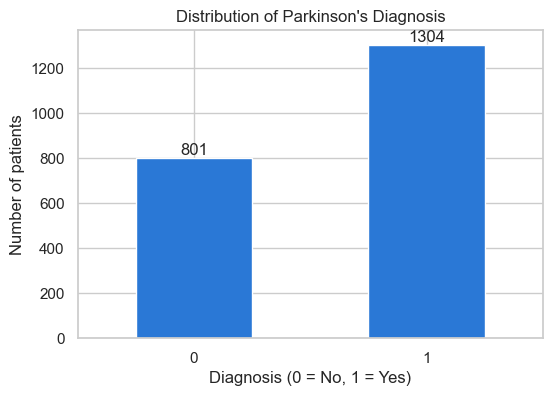

Diagnosis
1    0.619
0    0.381
Name: proportion, dtype: float64


In [4]:
# Class balance of the target
diagnosis_counts = data["Diagnosis"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
ax = diagnosis_counts.plot(kind="bar", color="#2a78d6", width=0.5)
ax.bar_label(ax.containers[0])
plt.title("Distribution of Parkinson's Diagnosis")
plt.xlabel("Diagnosis (0 = No, 1 = Yes)")
plt.ylabel("Number of patients")
plt.xticks(rotation=0)
plt.show()

print(data["Diagnosis"].value_counts(normalize=True).round(3))

About 62% of the records are positive. The classes are imbalanced but not severely, so I report recall, F1 and
AUC alongside accuracy.

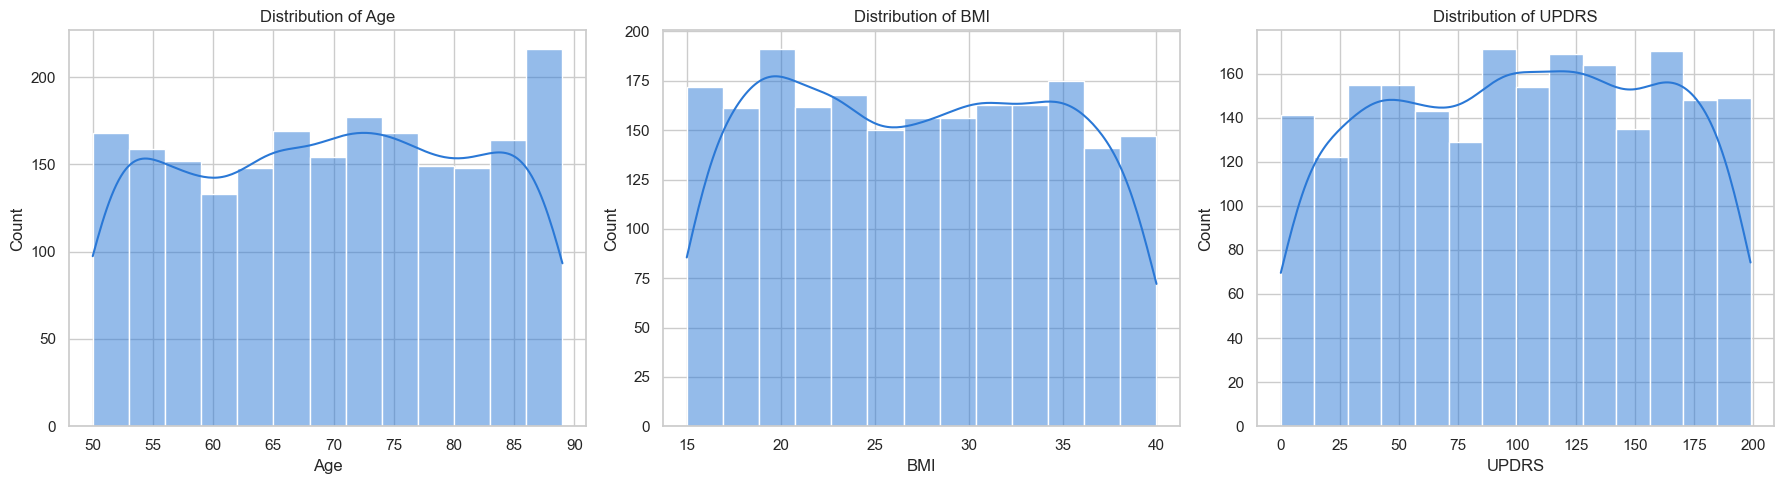

In [5]:
# Distributions of three continuous features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column in zip(axes, ["Age", "BMI", "UPDRS"]):
    sns.histplot(data[column], kde=True, ax=ax, color="#2a78d6")
    ax.set_title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

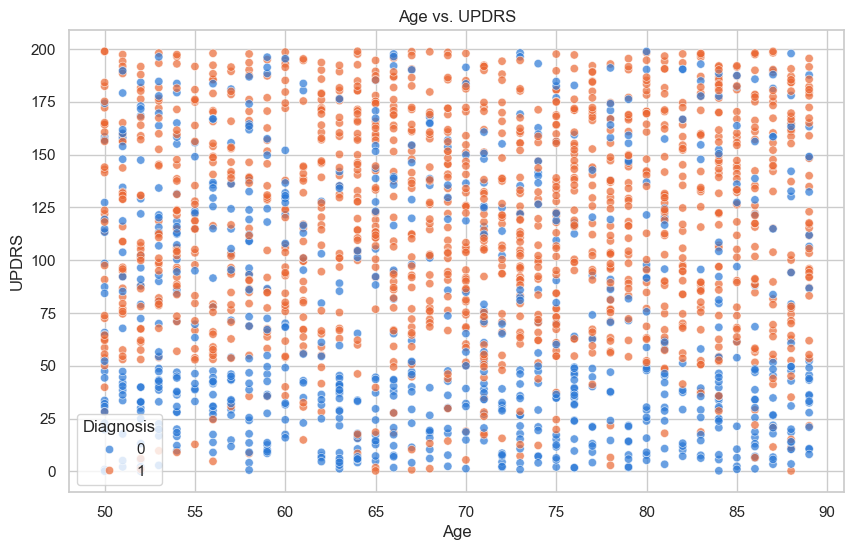

In [6]:
# Age vs UPDRS, coloured by diagnosis
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Age", y="UPDRS", hue="Diagnosis", data=data, palette=["#2a78d6", "#eb6834"], alpha=0.7)
plt.title("Age vs. UPDRS")
plt.legend(title="Diagnosis")
plt.show()

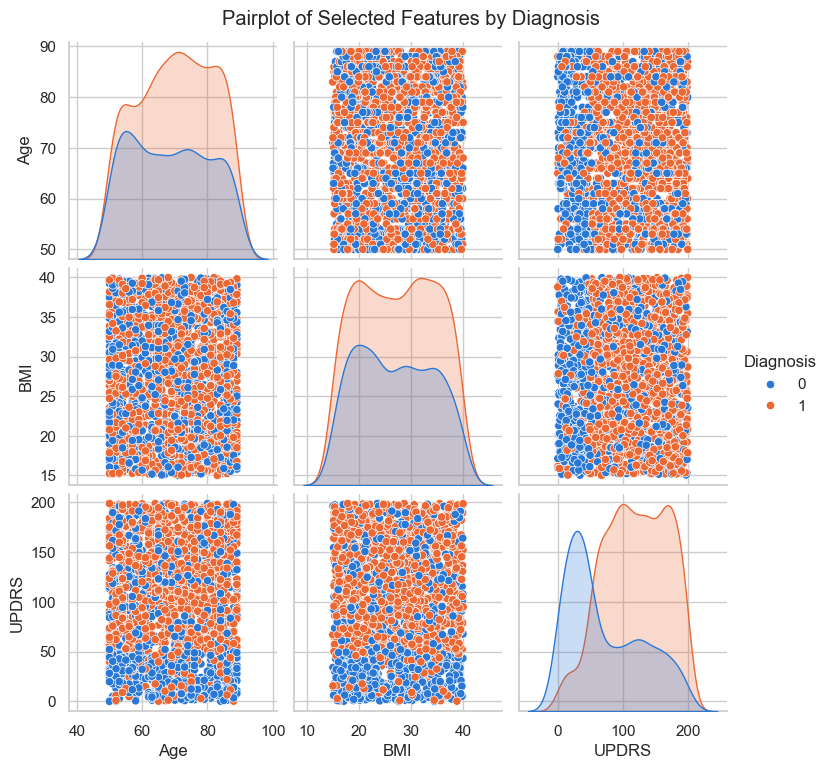

In [7]:
# Pairwise relationships between the same three features
sns.pairplot(data[["Age", "BMI", "UPDRS", "Diagnosis"]], hue="Diagnosis", palette=["#2a78d6", "#eb6834"])
plt.suptitle("Pairplot of Selected Features by Diagnosis", y=1.02)
plt.show()

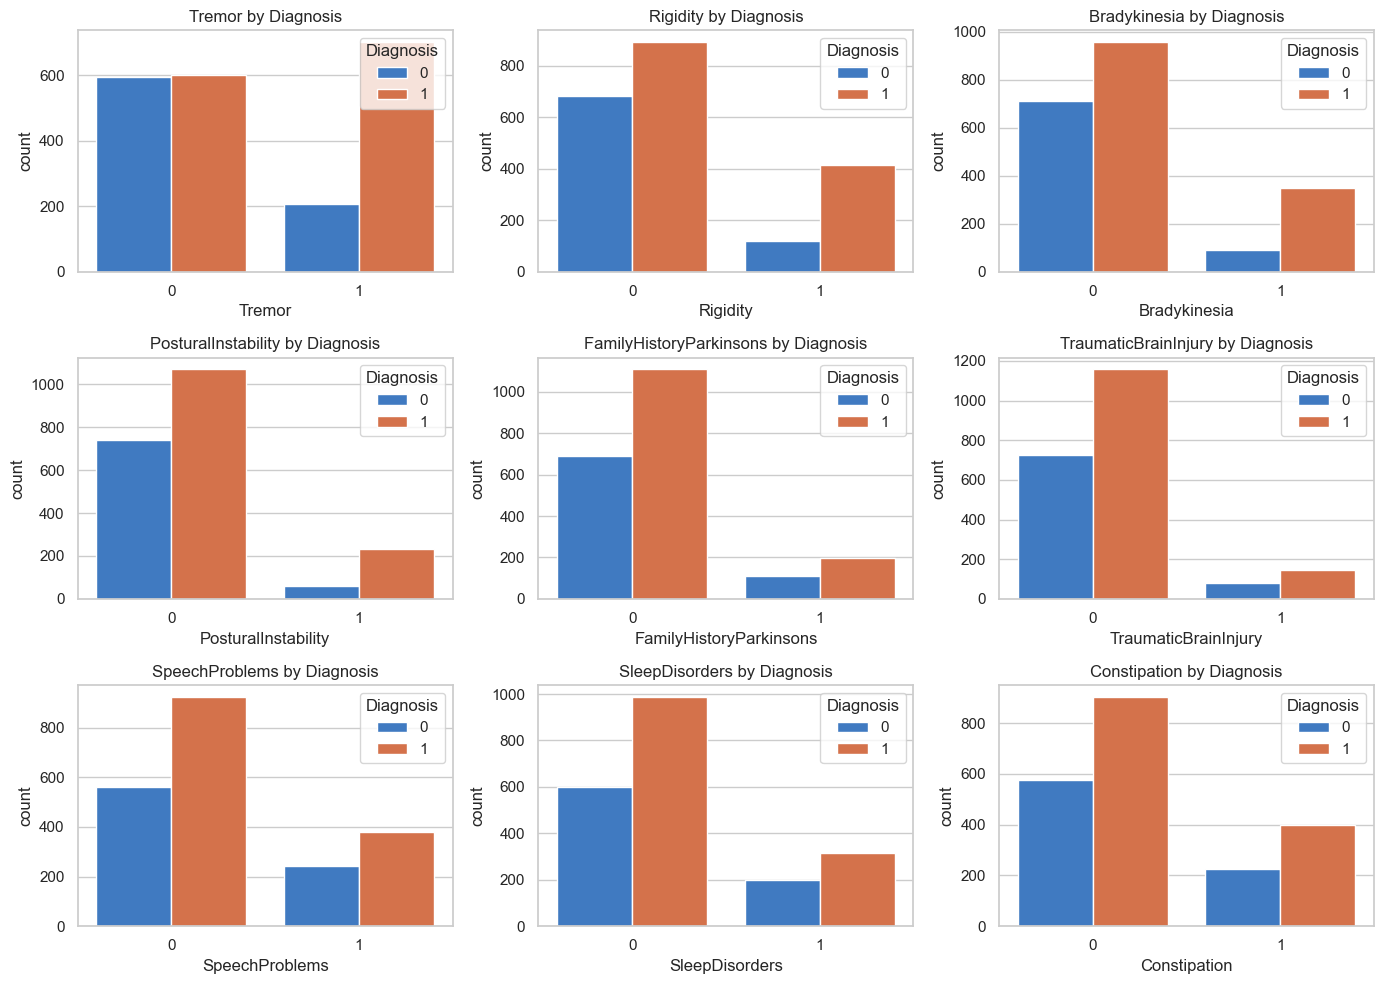

In [8]:
# Binary symptom and history flags, split by diagnosis
binary_features = [
    "Tremor", "Rigidity", "Bradykinesia", "PosturalInstability", "FamilyHistoryParkinsons",
    "TraumaticBrainInjury", "SpeechProblems", "SleepDisorders", "Constipation",
]
eda_data = data[binary_features + ["Diagnosis"]]

plt.figure(figsize=(14, 10))
for i, feature in enumerate(binary_features):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=feature, hue="Diagnosis", data=eda_data, palette=["#2a78d6", "#eb6834"])
    plt.title(f"{feature} by Diagnosis")
    plt.legend(title="Diagnosis", loc="upper right")
plt.tight_layout()
plt.show()

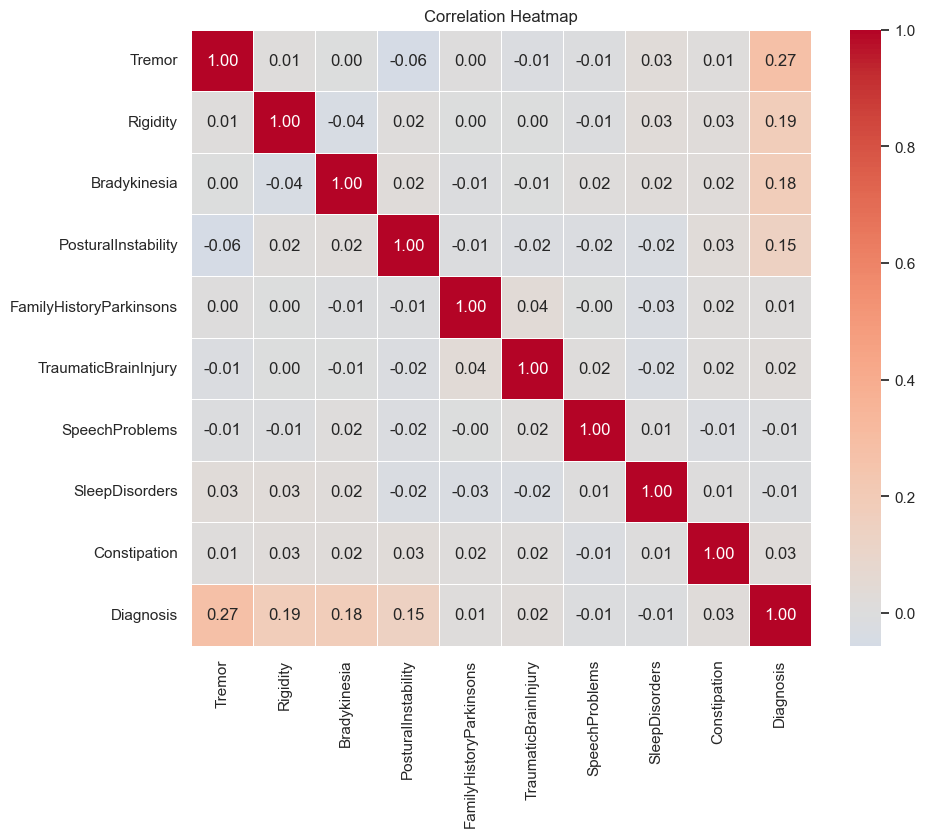

In [9]:
# Correlation between the binary flags and the diagnosis
plt.figure(figsize=(10, 8))
sns.heatmap(eda_data.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

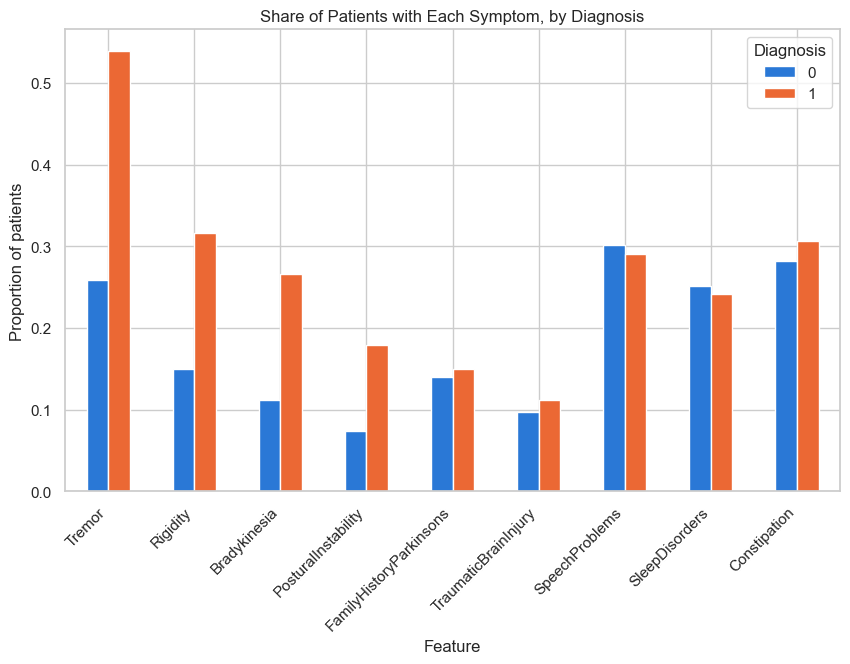

In [10]:
# Share of patients with each flag, by diagnosis
flag_rates = eda_data.groupby("Diagnosis").mean().T
flag_rates.plot(kind="bar", figsize=(10, 6), color=["#2a78d6", "#eb6834"])
plt.title("Share of Patients with Each Symptom, by Diagnosis")
plt.xlabel("Feature")
plt.ylabel("Proportion of patients")
plt.legend(title="Diagnosis")
plt.xticks(rotation=45, ha="right")
plt.show()

## 4. Train/test split and evaluation setup

- 80/20 train/test split with a fixed seed.
- Scaling is done inside a `Pipeline`, so the `StandardScaler` is fit on training data only. During
  cross-validation it is re-fit on the training folds of each split, so the validation fold never influences it.
- Tuning uses `GridSearchCV` with 5-fold cross-validation on the training set. The test set is scored exactly
  once per model, after the hyperparameters are fixed.
- Every model also gets a 5-fold CV accuracy on the training set, so models can be compared without looking at
  the test set.

In [11]:
X = data.drop(columns=["Diagnosis"])
y = data["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1684, 32) | Test: (421, 32)


In [12]:
results = []


def make_pipeline(model):
    """Scale the features, then fit the model. Trees don't need scaling, but it keeps every model on the same footing."""
    return Pipeline([("scaler", StandardScaler()), ("model", model)])


def fit_default(model):
    """Fit a model with its default settings. Also returns its 5-fold CV accuracy on the training set."""
    pipeline = make_pipeline(model)
    cv_accuracy = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy").mean()
    pipeline.fit(X_train, y_train)
    return pipeline, cv_accuracy


def tune(model, param_grid):
    """5-fold grid search on the training set only. Returns the best pipeline (refit on the full training set) and its CV accuracy."""
    search = GridSearchCV(make_pipeline(model), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    search.fit(X_train, y_train)
    print("Best parameters:", search.best_params_)
    return search.best_estimator_, search.best_score_


def evaluate(name, stage, model, cv_accuracy):
    """Score a fitted model on the test set, store the metrics and plot the confusion matrix."""
    y_pred = model.predict(X_test)
    # SVC has no predict_proba unless probability=True, so fall back to its decision scores for AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    metrics = {
        "Model": name,
        "Stage": stage,
        "CV Accuracy": cv_accuracy,
        "Train Accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_score),
    }
    results.append(metrics)

    print(f"{name} ({stage})")
    for metric, value in list(metrics.items())[2:]:
        print(f"  {metric}: {value:.4f}")
    print()
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["No PD", "PD"], yticklabels=["No PD", "PD"],
    )
    plt.title(f"{name} Confusion Matrix ({stage})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 5. Logistic Regression

A linear baseline. If it does well, the classes are close to linearly separable.

### Before tuning

Logistic Regression (Before tuning)
  CV Accuracy: 0.8135
  Train Accuracy: 0.8308
  Test Accuracy: 0.7767
  Recall: 0.8450
  F1: 0.8297
  AUC: 0.8794

              precision    recall  f1-score   support

           0       0.70      0.65      0.68       150
           1       0.81      0.85      0.83       271

    accuracy                           0.78       421
   macro avg       0.76      0.75      0.75       421
weighted avg       0.77      0.78      0.77       421



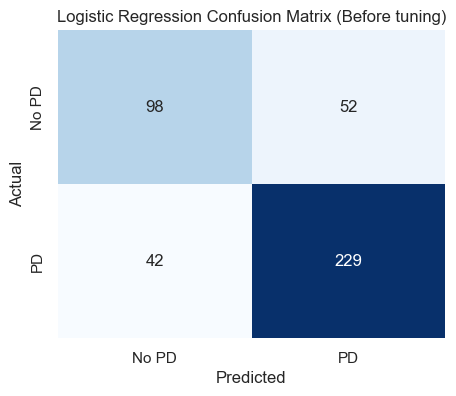

In [13]:
log_reg_before, cv_accuracy = fit_default(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
evaluate("Logistic Regression", "Before tuning", log_reg_before, cv_accuracy)

### After tuning
Search over the regularisation strength and the penalty type (L1 can drop uninformative features).

Best parameters: {'model__C': 0.1, 'model__penalty': 'l1'}
Logistic Regression (After tuning)
  CV Accuracy: 0.8165
  Train Accuracy: 0.8254
  Test Accuracy: 0.7862
  Recall: 0.8376
  F1: 0.8346
  AUC: 0.8793

              precision    recall  f1-score   support

           0       0.70      0.69      0.70       150
           1       0.83      0.84      0.83       271

    accuracy                           0.79       421
   macro avg       0.77      0.77      0.77       421
weighted avg       0.79      0.79      0.79       421



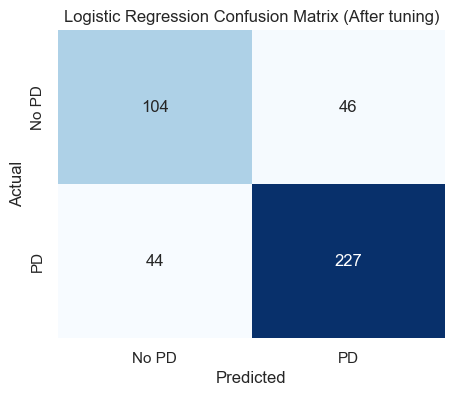

In [14]:
log_reg_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
}
# liblinear supports both L1 and L2 penalties
log_reg_after, cv_accuracy = tune(LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE), log_reg_grid)
evaluate("Logistic Regression", "After tuning", log_reg_after, cv_accuracy)

## 6. Gaussian Naive Bayes

A fast probabilistic model that assumes the features are independent given the class.

### Before tuning

Naive Bayes (Before tuning)
  CV Accuracy: 0.7910
  Train Accuracy: 0.8082
  Test Accuracy: 0.7791
  Recall: 0.8155
  F1: 0.8262
  AUC: 0.8660

              precision    recall  f1-score   support

           0       0.68      0.71      0.70       150
           1       0.84      0.82      0.83       271

    accuracy                           0.78       421
   macro avg       0.76      0.76      0.76       421
weighted avg       0.78      0.78      0.78       421



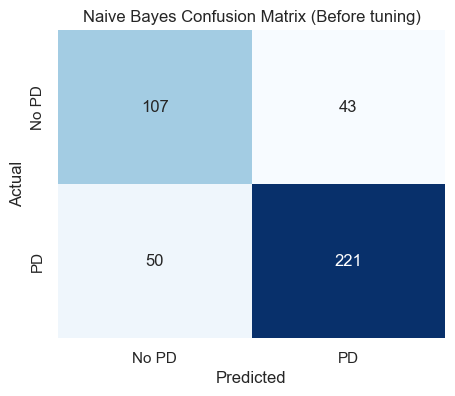

In [15]:
nb_before, cv_accuracy = fit_default(GaussianNB())
evaluate("Naive Bayes", "Before tuning", nb_before, cv_accuracy)

### After tuning
Gaussian Naive Bayes has one real hyperparameter, `var_smoothing`, which adds a small amount to every feature
variance for stability. The class priors are left to be estimated from the training data.

Best parameters: {'model__var_smoothing': 1.0}
Naive Bayes (After tuning)
  CV Accuracy: 0.8076
  Train Accuracy: 0.8302
  Test Accuracy: 0.7933
  Recall: 0.8487
  F1: 0.8410
  AUC: 0.8807

              precision    recall  f1-score   support

           0       0.72      0.69      0.71       150
           1       0.83      0.85      0.84       271

    accuracy                           0.79       421
   macro avg       0.78      0.77      0.77       421
weighted avg       0.79      0.79      0.79       421



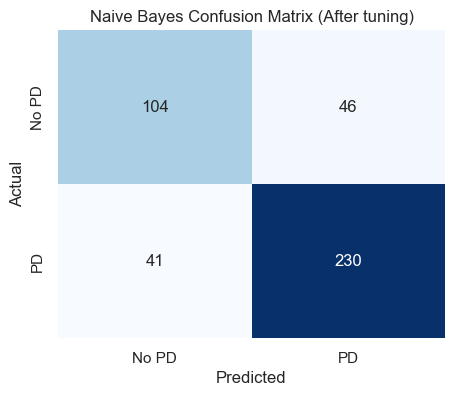

In [16]:
nb_grid = {"model__var_smoothing": np.logspace(-9, 0, 10)}
nb_after, cv_accuracy = tune(GaussianNB(), nb_grid)
evaluate("Naive Bayes", "After tuning", nb_after, cv_accuracy)

## 7. Support Vector Machine

SVMs are sensitive to feature scale, so the scaler in the pipeline matters most here.

### Before tuning

SVM (Before tuning)
  CV Accuracy: 0.8266
  Train Accuracy: 0.9418
  Test Accuracy: 0.7838
  Recall: 0.8561
  F1: 0.8360
  AUC: 0.8781

              precision    recall  f1-score   support

           0       0.72      0.65      0.68       150
           1       0.82      0.86      0.84       271

    accuracy                           0.78       421
   macro avg       0.77      0.75      0.76       421
weighted avg       0.78      0.78      0.78       421



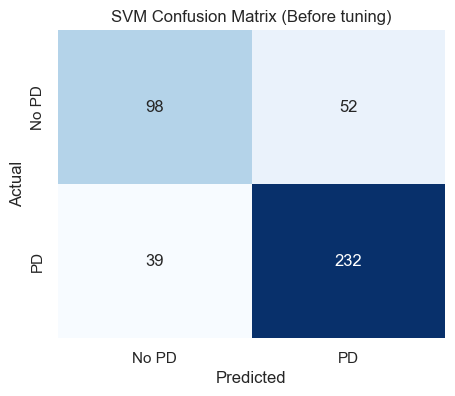

In [17]:
svm_before, cv_accuracy = fit_default(SVC(random_state=RANDOM_STATE))
evaluate("SVM", "Before tuning", svm_before, cv_accuracy)

### After tuning
Search over the kernel, the regularisation strength `C` (higher = less regularisation) and `gamma`, which
controls how far the influence of a single training point reaches for the RBF and sigmoid kernels.

Best parameters: {'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}


SVM (After tuning)
  CV Accuracy: 0.8379
  Train Accuracy: 0.9430
  Test Accuracy: 0.8076
  Recall: 0.8303
  F1: 0.8475
  AUC: 0.8885

              precision    recall  f1-score   support

           0       0.71      0.77      0.74       150
           1       0.87      0.83      0.85       271

    accuracy                           0.81       421
   macro avg       0.79      0.80      0.79       421
weighted avg       0.81      0.81      0.81       421



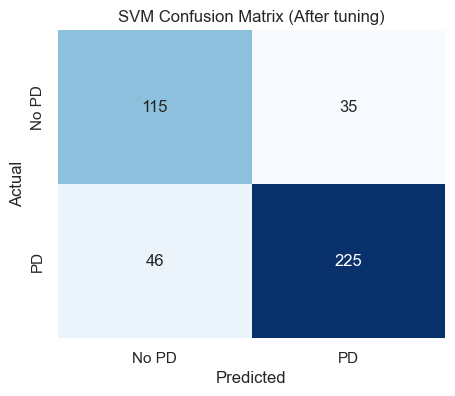

In [18]:
svm_grid = {
    "model__kernel": ["linear", "rbf", "sigmoid"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01, 0.001],
}
svm_after, cv_accuracy = tune(SVC(random_state=RANDOM_STATE), svm_grid)
evaluate("SVM", "After tuning", svm_after, cv_accuracy)

## 8. Gradient Boosting

An ensemble of shallow trees built one after another, each correcting the errors of the previous ones.

### Before tuning

Gradient Boosting (Before tuning)
  CV Accuracy: 0.9353
  Train Accuracy: 0.9703
  Test Accuracy: 0.9074
  Recall: 0.9114
  F1: 0.9268
  AUC: 0.9540

              precision    recall  f1-score   support

           0       0.85      0.90      0.87       150
           1       0.94      0.91      0.93       271

    accuracy                           0.91       421
   macro avg       0.90      0.91      0.90       421
weighted avg       0.91      0.91      0.91       421



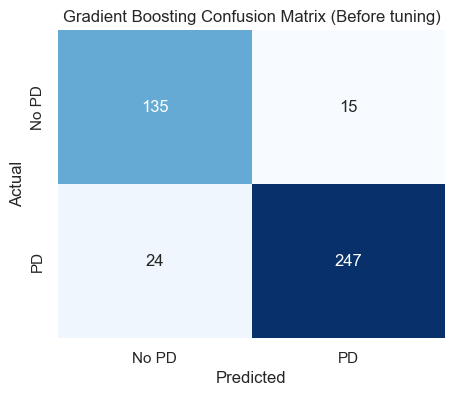

In [19]:
gb_before, cv_accuracy = fit_default(GradientBoostingClassifier(random_state=RANDOM_STATE))
evaluate("Gradient Boosting", "Before tuning", gb_before, cv_accuracy)

### After tuning
Search over the number of trees, learning rate and tree depth, plus `subsample` (row sampling per tree) as a
regulariser.

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Gradient Boosting (After tuning)
  CV Accuracy: 0.9382
  Train Accuracy: 0.9935
  Test Accuracy: 0.9216
  Recall: 0.9151
  F1: 0.9376
  AUC: 0.9580

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       150
           1       0.96      0.92      0.94       271

    accuracy                           0.92       421
   macro avg       0.91      0.92      0.92       421
weighted avg       0.92      0.92      0.92       421



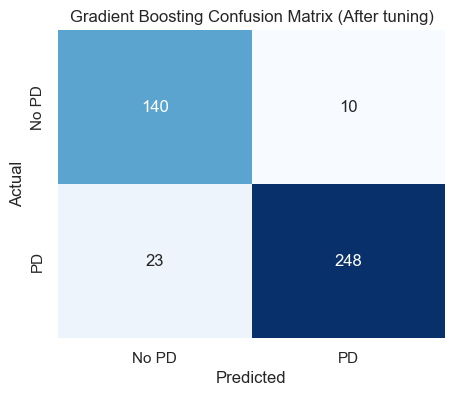

In [20]:
gb_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.8, 1.0],
}
gb_after, cv_accuracy = tune(GradientBoostingClassifier(random_state=RANDOM_STATE), gb_grid)
evaluate("Gradient Boosting", "After tuning", gb_after, cv_accuracy)

## 9. XGBoost

A regularised, faster implementation of gradient boosting.

### Before tuning

XGBoost (Before tuning)
  CV Accuracy: 0.9264
  Train Accuracy: 1.0000
  Test Accuracy: 0.9311
  Recall: 0.9299
  F1: 0.9456
  AUC: 0.9608

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       150
           1       0.96      0.93      0.95       271

    accuracy                           0.93       421
   macro avg       0.92      0.93      0.93       421
weighted avg       0.93      0.93      0.93       421



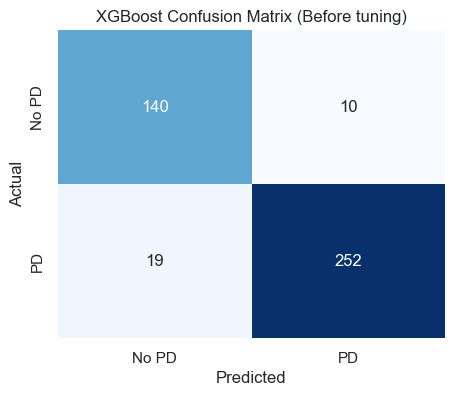

In [21]:
xgb_before, cv_accuracy = fit_default(XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE))
evaluate("XGBoost", "Before tuning", xgb_before, cv_accuracy)

### After tuning
The default model reaches 100% training accuracy, which means it has memorised the training set. The grid
therefore includes regularisation options as well as the usual size/learning-rate settings:

- `min_child_weight`: a larger value stops the trees from creating leaves for very few samples
- `subsample`: each tree sees only a random share of the rows
- `colsample_bytree`: each tree sees only a random share of the features

The best combination is chosen by cross-validation on the training set. The test set is not touched until the
final `evaluate` call.

Best parameters: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__min_child_weight': 5, 'model__n_estimators': 50, 'model__subsample': 1.0}
XGBoost (After tuning)
  CV Accuracy: 0.9412
  Train Accuracy: 0.9650
  Test Accuracy: 0.9240
  Recall: 0.9262
  F1: 0.9401
  AUC: 0.9580

              precision    recall  f1-score   support

           0       0.87      0.92      0.90       150
           1       0.95      0.93      0.94       271

    accuracy                           0.92       421
   macro avg       0.91      0.92      0.92       421
weighted avg       0.93      0.92      0.92       421



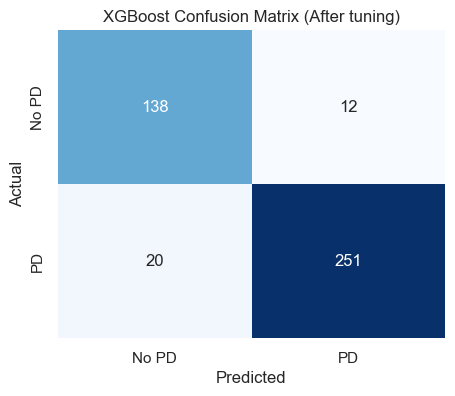

In [22]:
xgb_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 5],
    "model__subsample": [0.7, 1.0],
    "model__colsample_bytree": [0.7, 1.0],
}
# n_jobs=1 for the model because the grid search already runs in parallel
xgb_after, cv_accuracy = tune(XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1), xgb_grid)
evaluate("XGBoost", "After tuning", xgb_after, cv_accuracy)

**Overfitting note.** The default XGBoost model fits the training set perfectly (100% train accuracy) but scores
92.6% in cross-validation, a gap of about 7 points. The tuned model picked shallower trees (`max_depth=3`),
fewer of them (`n_estimators=50`), `min_child_weight=5` and `colsample_bytree=0.7`. That brings train accuracy
down to 96.5% and CV accuracy up to 94.1%, so the gap shrinks to about 2.5 points. Some overfitting remains,
which is normal for boosted trees on a dataset this small.

On the test set the default model happens to score slightly higher (93.1% vs 92.4%). That is a difference of
3 records out of 421, well inside the noise of a test set this size, and choosing the default model because of
it would be selecting on the test set. The tuned model is the one cross-validation supports.

## 10. Results

All ten models on the same held-out test set (421 records).

In [23]:
results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Stage,CV Accuracy,Train Accuracy,Test Accuracy,Recall,F1,AUC
0,Logistic Regression,Before tuning,0.8135,0.8308,0.7767,0.8450,0.8297,0.8794
1,Logistic Regression,After tuning,0.8165,0.8254,0.7862,0.8376,0.8346,0.8793
2,Naive Bayes,Before tuning,0.7910,0.8082,0.7791,0.8155,0.8262,0.8660
3,Naive Bayes,After tuning,0.8076,0.8302,0.7933,0.8487,0.8410,0.8807
4,SVM,Before tuning,0.8266,0.9418,0.7838,0.8561,0.8360,0.8781
5,SVM,After tuning,0.8379,0.9430,0.8076,0.8303,0.8475,0.8885
6,Gradient Boosting,Before tuning,0.9353,0.9703,0.9074,0.9114,0.9268,0.9540
7,Gradient Boosting,After tuning,0.9382,0.9935,0.9216,0.9151,0.9376,0.9580
8,XGBoost,Before tuning,0.9264,1.0000,0.9311,0.9299,0.9456,0.9608
9,XGBoost,After tuning,0.9412,0.9650,0.9240,0.9262,0.9401,0.9580


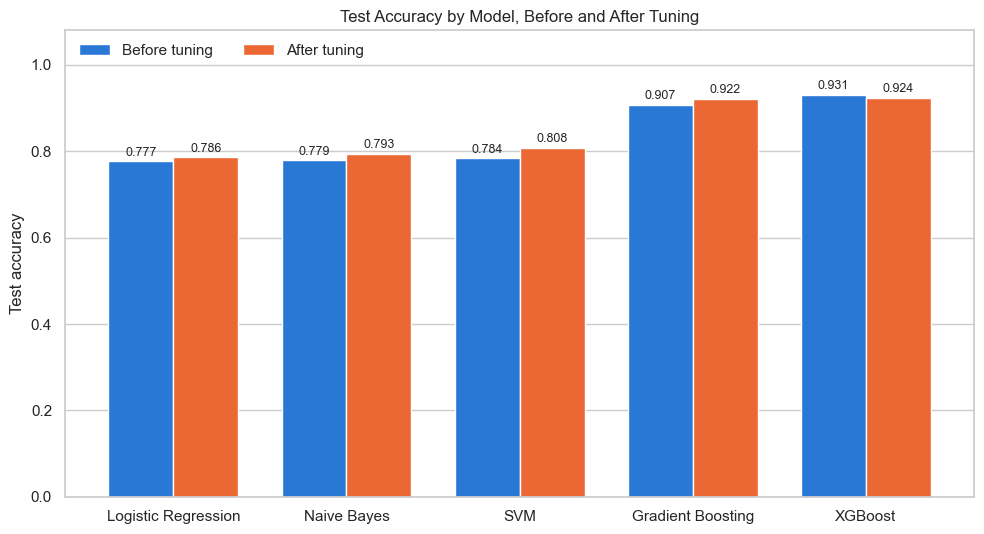

In [24]:
# Test accuracy per model, before vs after tuning
accuracy_table = results_df.pivot(index="Model", columns="Stage", values="Test Accuracy")
accuracy_table = accuracy_table.loc[results_df["Model"].unique(), ["Before tuning", "After tuning"]]

ax = accuracy_table.plot(kind="bar", figsize=(10, 5.5), color=["#2a78d6", "#eb6834"], width=0.75, edgecolor="white")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)
ax.set_title("Test Accuracy by Model, Before and After Tuning")
ax.set_xlabel("")
ax.set_ylabel("Test accuracy")
ax.set_ylim(0, 1.08)
ax.grid(axis="x", visible=False)
ax.legend(title="", loc="upper left", ncols=2, frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()

# Saved for the README
images_dir = DATA_PATH.parent.parent / "images"
images_dir.mkdir(exist_ok=True)
plt.savefig(images_dir / "test_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Conclusion

**Best model: tuned XGBoost.** It has the highest cross-validated accuracy (94.1%), which is the fair basis for
choosing a model, and on the held-out test set it scores:

| Metric | Tuned XGBoost (test set) |
|---|---|
| Accuracy | 92.40% |
| Recall | 92.62% |
| F1 | 94.01% |
| ROC AUC | 95.80% |

**What the comparison shows**
- The two boosted-tree models (XGBoost and Gradient Boosting) are clearly ahead at 92–93% test accuracy. The
  other three models sit at 78–81%.
- Tuned Gradient Boosting (92.16%) and tuned XGBoost (92.40%) are effectively tied. The gap is one test record.
- Tuning helped only a little: between 1 and 2.5 points of test accuracy for four models, and slightly negative
  for XGBoost on this particular test set. The choice of algorithm mattered far more than the hyperparameters.

**Overfitting**
- Default XGBoost reaches 100% training accuracy and tuned Gradient Boosting 99.4%, against 92–93% on the test
  set. These models memorise part of the training data. Regularisation narrowed the gap for XGBoost
  (96.5% train vs 92.4% test) but did not remove it.

**Limitations**
- **Synthetic data.** The dataset was generated for educational purposes, so these numbers say nothing about
  performance on real patients.
- **Small test set.** With 421 test records, the 95% confidence interval on 92.4% accuracy is roughly ±2.5
  points. Differences of a point or two between models are not meaningful.
- **Single train/test split.** Results come from one 80/20 split with one seed. Repeated or nested
  cross-validation would give more stable estimates.
- **UPDRS as a feature.** UPDRS is a rating scale used to assess people who already have Parkinson's, so in a
  real screening setting it would not be available before diagnosis. Its presence likely makes the task easier
  than real early detection.
- **Accuracy as the tuning metric.** In a medical setting a missed case costs more than a false alarm, so
  tuning for recall or choosing a decision threshold would be a sensible next step.